# TASK 06 — Momentum: Escape a Shallow Minimum

In this task, I will compare plain gradient descent with gradient descent
using momentum on the non-convex function:

f(x) = x⁴ - 4x² + 0.4x

Its gradient is:

f'(x) = 4x³ - 8x + 0.4

I will start both optimizers from the same point on the shallow side
and observe that plain gradient descent gets trapped while momentum
can carry the point through the hill toward the deeper global minimum.

## Momentum

Plain gradient descent only considers the current gradient.

Momentum keeps a velocity from previous steps:

v = beta * v - lr * gradient

x = x + v

Here:

beta = 0.9

The parameter beta controls how much previous velocity is remembered.

- beta close to 0 → little memory, similar to plain gradient descent
- beta close to 1 → strong memory and more inertia

The velocity allows the optimizer to build speed while moving downhill,
which can help it pass through a shallow minimum.

TASK 06 RESULTS
Starting point: 2.2
Learning rate: 0.01
Momentum beta: 0.9
Steps: 800

Plain Gradient Descent
Final x = 1.388517
Final f(x) = -3.439406

Momentum Gradient Descent
Final x = -1.438580
Final f(x) = -4.570600


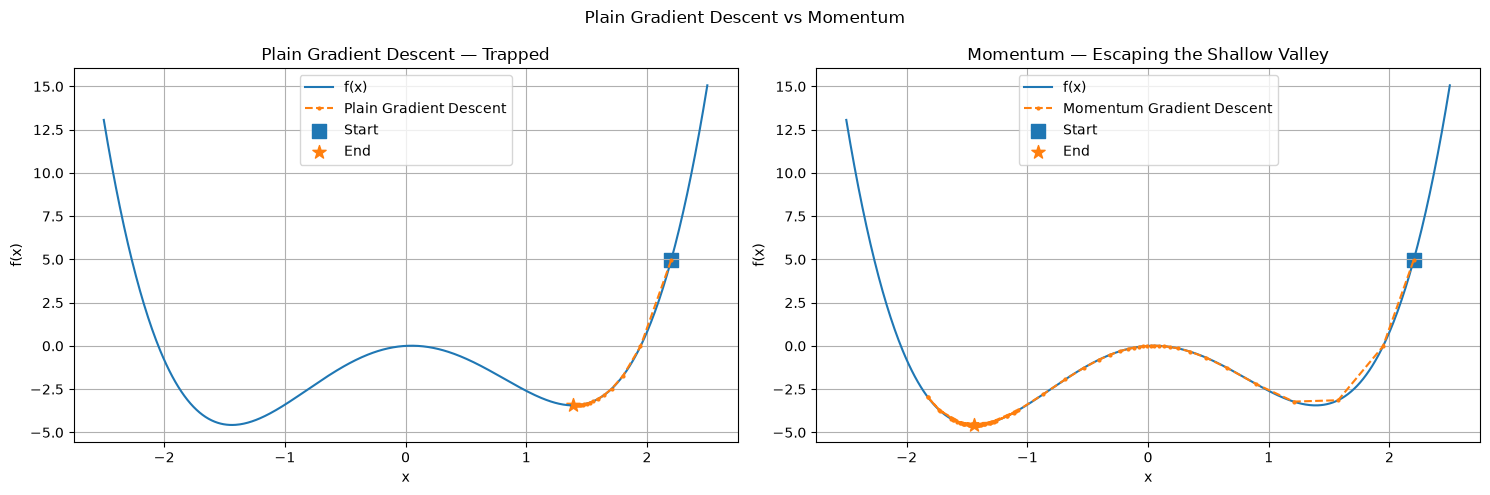


FINAL COMPARISON
Plain GD     : x = 1.388517
Momentum GD  : x = -1.438580

The two optimizers start from exactly the same point, but momentum keeps accumulated velocity.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Two-minima function from TASK 04
# ============================================================

def f(x):
    return x**4 - 4*x**2 + 0.4*x


def grad(x):
    return 4*x**3 - 8*x + 0.4


# ============================================================
# Plain Gradient Descent
# ============================================================

def gradient_descent(grad_fn, start, lr, steps):
    x = start
    history = [x]

    for _ in range(steps):
        x = x - lr * grad_fn(x)
        history.append(x)

    return np.array(history)


# ============================================================
# Momentum Gradient Descent
# ============================================================

def momentum_gd(start, lr=0.01, beta=0.9, steps=800):

    x = start
    v = 0.0

    history = [x]

    for _ in range(steps):

        # Update velocity
        v = beta * v - lr * grad(x)

        # Update position
        x = x + v

        history.append(x)

    return np.array(history)


# ============================================================
# Same Starting Point
# ============================================================

start = 2.2

lr = 0.01
beta = 0.9
steps = 800


# Plain gradient descent
plain_path = gradient_descent(
    grad_fn=grad,
    start=start,
    lr=lr,
    steps=steps
)


# Momentum gradient descent
momentum_path = momentum_gd(
    start=start,
    lr=lr,
    beta=beta,
    steps=steps
)


# ============================================================
# Print Results
# ============================================================

print("TASK 06 RESULTS")
print("=" * 60)

print(f"Starting point: {start}")
print(f"Learning rate: {lr}")
print(f"Momentum beta: {beta}")
print(f"Steps: {steps}")

print("\nPlain Gradient Descent")
print(f"Final x = {plain_path[-1]:.6f}")
print(f"Final f(x) = {f(plain_path[-1]):.6f}")

print("\nMomentum Gradient Descent")
print(f"Final x = {momentum_path[-1]:.6f}")
print(f"Final f(x) = {f(momentum_path[-1]):.6f}")


# ============================================================
# Plot Both Paths Side by Side
# ============================================================

x_values = np.linspace(-2.5, 2.5, 600)
y_values = f(x_values)


fig, axes = plt.subplots(1, 2, figsize=(15, 5))


# ------------------------------------------------------------
# Plain Gradient Descent
# ------------------------------------------------------------

axes[0].plot(
    x_values,
    y_values,
    label="f(x)"
)

axes[0].plot(
    plain_path,
    f(plain_path),
    marker="o",
    markersize=2,
    linestyle="--",
    label="Plain Gradient Descent"
)

axes[0].scatter(
    start,
    f(start),
    s=100,
    marker="s",
    label="Start"
)

axes[0].scatter(
    plain_path[-1],
    f(plain_path[-1]),
    s=100,
    marker="*",
    label="End"
)

axes[0].set_title("Plain Gradient Descent — Trapped")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].grid(True)
axes[0].legend()


# ------------------------------------------------------------
# Momentum Gradient Descent
# ------------------------------------------------------------

axes[1].plot(
    x_values,
    y_values,
    label="f(x)"
)

axes[1].plot(
    momentum_path,
    f(momentum_path),
    marker="o",
    markersize=2,
    linestyle="--",
    label="Momentum Gradient Descent"
)

axes[1].scatter(
    start,
    f(start),
    s=100,
    marker="s",
    label="Start"
)

axes[1].scatter(
    momentum_path[-1],
    f(momentum_path[-1]),
    s=100,
    marker="*",
    label="End"
)

axes[1].set_title("Momentum — Escaping the Shallow Valley")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")
axes[1].grid(True)
axes[1].legend()


plt.suptitle("Plain Gradient Descent vs Momentum")
plt.tight_layout()
plt.show()


# ============================================================
# Show Final Positions Together
# ============================================================

print("\nFINAL COMPARISON")
print("=" * 60)

print(
    f"Plain GD     : x = {plain_path[-1]:.6f}"
)

print(
    f"Momentum GD  : x = {momentum_path[-1]:.6f}"
)

print(
    "\nThe two optimizers start from exactly the same point, "
    "but momentum keeps accumulated velocity."
)

## Result

Both optimizers start from the same point, x = 2.2.

Plain gradient descent loses its motion as it approaches the shallow
local minimum, so its gradient becomes approximately zero and it gets
trapped there.

Momentum remembers previous movement through the velocity term, so it
can carry enough inertia to cross the hill and continue toward the
deeper global minimum.

In physical terms, plain gradient descent is like a ball that stops as
soon as the slope becomes flat, while momentum is like a ball with
inertia that can roll through a shallow valley and climb the next hill.

## Questions

### What does beta control?

Beta controls how much of the previous velocity is retained.

When beta is close to 0, there is very little memory and momentum behaves
more like ordinary gradient descent. When beta is close to 1, more
previous velocity is retained, producing stronger inertia.

### Why is Adam popular?

Adam combines momentum with adaptive learning rates for individual
parameters. This allows it to use accumulated gradient information
while automatically adjusting the step size for different parameters.

### When can momentum hurt?

Momentum can hurt when the accumulated velocity becomes too large and
causes the optimizer to overshoot a good minimum. This can lead to
oscillation or instability, especially when the learning rate or
momentum is too high.